# 01 — Data audit and development-data EDA

**CSE437: Data Science | Group 15**

Sections 1–10 retain the original full-source quality audit from the raw-data audit. Those summaries were inspected before the holdout was defined; they are not test-set performance results. Sections 11–15 contain descriptive analysis relationship analysis using only the frozen 95,415 development bookings. Notebook 02 implements eligibility and preprocessing, and the committed processed/split files supply the inputs here.

The original proposal, research questions, source data, and frozen splits are unchanged. No predictive model is trained, no statistical feature selection is fitted, and no test feature/target relationships are analyzed. The predeclared focus remains lead time, deposit type, and prior cancellations.


**Execution record:** These cells were executed sequentially in a fresh Python process using an IPython shell, with their actual outputs captured below. This environment could not launch a separate Jupyter kernel. A normal fresh-kernel Jupyter run remains to be checked before final submission.


## Running the analysis

[Open in Google Colab](https://colab.research.google.com/github/faraaz1027-cloud/cse437-hotel-cancellation-15/blob/main/notebooks/01_data_audit_and_eda.ipynb)

Choose **Runtime > Run all**. Setup downloads the project, verifies inputs and installs pinned analysis packages. If it reports **SETUP PAUSED**, choose **Runtime > Restart session**, then **Run all** again; do not delete the runtime. No manual data upload or Drive mount is required. CPU is sufficient.

The source revision is printed during setup. Existing local checkouts are not reset. Download the executed notebook to retain outputs. Recorded outputs below are historical; path/label cleanup and this setup cell do not constitute a new execution. Current Colab execution remains unverified. Development reruns can differ numerically; cached final evaluation is not a new model fit.

In [ ]:
"""Self-contained Colab bootstrap embedded verbatim in the five notebooks.

Uses only the standard library until the analysis dependencies are ready.
Does not modify a user's checkout, install Jupyter, or weaken scientific checks.
"""
import hashlib
import importlib.metadata
import os
from pathlib import Path
import subprocess
import sys


SOURCE_URL = 'https://github.com/faraaz1027-cloud/cse437-hotel-cancellation-15.git'
SOURCE_COMMIT = '__CLEAN_LAYOUT_COMMIT__'
ANALYSIS_PACKAGES = {
    'numpy': ('numpy', '2.3.5'),
    'pandas': ('pandas', '2.2.3'),
    'scipy': ('scipy', '1.17.0'),
    'scikit-learn': ('sklearn', '1.8.0'),
    'matplotlib': ('matplotlib', '3.10.8'),
    'seaborn': ('seaborn', '0.13.2'),
    'joblib': ('joblib', '1.5.3'),
}
PROTECTED_FILES = {
    'data/raw/hotel_bookings.csv':
        '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06',
    'data/processed/results/tuning/final_selection.json':
        '68c4072f5c95e3a9f927a8b70a9e96aea8adbd4f7509f4d1c30ba6f7889f3b1b',
    'models/final_logistic_regression.joblib':
        '498112adf28d66f22f84f76101187c7a94eefeda62b7a92b45f1f9152790e097',
}


def in_colab():
    return 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))


def installed_version(package):
    try:
        return importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        return None


def ensure_analysis_packages():
    # Do not replace Colab's IPython, ipykernel, or notebook server.
    changed = {name for name, (_, version) in ANALYSIS_PACKAGES.items()
               if installed_version(name) != version}
    loaded_before = {name for name, (module, _) in ANALYSIS_PACKAGES.items()
                     if module in sys.modules}
    if changed:
        print('Installing pinned analysis packages. This may take a few minutes.', flush=True)
        subprocess.run([sys.executable, '-m', 'pip', 'install', '--disable-pip-version-check',
                        *[f'{name}=={version}' for name, (_, version)
                          in ANALYSIS_PACKAGES.items()]], check=True)
    for name, (_, version) in ANALYSIS_PACKAGES.items():
        if installed_version(name) != version:
            raise RuntimeError(f'{name} installation did not reach {version}; stop and inspect pip output.')
    stale = changed & loaded_before
    for name, (module, version) in ANALYSIS_PACKAGES.items():
        loaded = sys.modules.get(module)
        if loaded is not None and getattr(loaded, '__version__', version) != version:
            stale.add(name)
    if stale:
        raise RuntimeError(
            'SETUP PAUSED: packages already loaded in memory need a restart: '
            + ', '.join(sorted(stale))
            + '. Choose Runtime > Restart session, then Runtime > Run all. '
              'Do not disconnect/delete the runtime. Installed packages are retained.')


def repository_at_or_above(folder):
    folder = Path(folder).resolve()
    for candidate in (folder, *folder.parents):
        if ((candidate / 'src/eligibility.py').is_file()
                and (candidate / 'data/processed/splits/validation_split_plan.json').is_file()
                and (candidate / 'notebooks').is_dir()):
            return candidate
    return None


def checked_checkout(destination):
    destination = Path(destination)
    if not destination.exists():
        destination.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(['git', '-c', 'core.autocrlf=false', 'clone', '--no-checkout', SOURCE_URL, str(destination)], check=True)
        subprocess.run(['git', '-C', str(destination), 'checkout', '--detach', SOURCE_COMMIT], check=True)
    elif not (destination / '.git').is_dir():
        raise RuntimeError('The setup folder already exists but is not a Git checkout. '
                           'Use a fresh Colab runtime; no existing files were overwritten.')
    head = subprocess.check_output(['git', '-C', str(destination), 'rev-parse', 'HEAD'], text=True).strip()
    origin = subprocess.check_output(['git', '-C', str(destination), 'remote', 'get-url', 'origin'], text=True).strip()
    if head != SOURCE_COMMIT or origin != SOURCE_URL:
        raise RuntimeError('Existing checkout has a different source/version. '
                           'Use a fresh runtime. Setup will not reset or overwrite it.')
    return destination


def verify_inputs(root):
    for relative, expected in PROTECTED_FILES.items():
        path = Path(root) / relative
        if not path.is_file():
            raise FileNotFoundError(f'Missing required project input: {relative}')
        if hashlib.sha256(path.read_bytes()).hexdigest() != expected:
            raise RuntimeError(f'Protected input differs: {relative}. No replacement was attempted.')


def prepare_colab():
    if not in_colab():
        # The ordinary local/verification workflow already supplies its environment.
        return None
    if sys.version_info[:2] not in ((3, 12), (3, 13)):
        raise RuntimeError('These package pins need Python 3.12 or 3.13. '
                           'Use a compatible Colab runtime, or the documented local Python 3.12 setup.')
    ensure_analysis_packages()
    root = repository_at_or_above(Path.cwd())
    if root is None:
        root = checked_checkout(Path('/content/cse437-colab') / SOURCE_COMMIT)
        print('Analysis source commit:', SOURCE_COMMIT)
    else:
        print('Using the existing project working directory; no checkout reset or update.')
    verify_inputs(root)
    os.chdir(root)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    print('Setup ready:', root)
    print('CPU runtime is sufficient. No Google Drive mount or manual data upload is needed.')
    print('Development scores may vary; notebook 05 verifies the original cached test results.')
    return root


if __name__ == '__main__':
    prepare_colab()


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data' / 'raw').is_dir() and (p / 'notebooks').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open the notebook from the repository or its notebooks directory.')
RAW_PATH = ROOT / 'data' / 'raw' / 'hotel_bookings.csv'
if not RAW_PATH.is_file():
    raise FileNotFoundError('Place the original hotel_bookings.csv in data/raw/. See data/README.md.')
pd.set_option('display.max_rows', 40)
versions = {'python': platform.python_version(), 'pandas': pd.__version__,
            'numpy': np.__version__, 'matplotlib': matplotlib.__version__}
display(pd.Series(versions, name='Audit runtime').to_frame())


,Audit runtime
python,3.12.13
pandas,2.2.3
numpy,2.3.5
matplotlib,3.10.8


## 1. Verify the input and schema

The SHA-256 value identifies the exact uploaded file. A changed source version requires a fresh audit. This notebook never writes to the raw input.


In [2]:
EXPECTED_SHA256 = '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06'
raw_bytes = RAW_PATH.read_bytes()
source_sha = hashlib.sha256(raw_bytes).hexdigest()
assert source_sha == EXPECTED_SHA256, 'Input differs from the audited source; review and re-audit.'
raw = pd.read_csv(RAW_PATH)
assert raw.shape == (119390, 32), 'Unexpected dimensions.'
assert raw['is_canceled'].notna().all()
assert set(raw['is_canceled'].unique()) == {0, 1}, 'Unexpected target coding.'
file_record = {'filename': RAW_PATH.name, 'bytes': len(raw_bytes),
               'decimal_MB': len(raw_bytes) / 1_000_000,
               'MiB': len(raw_bytes) / 1024**2,
               'rows': len(raw), 'columns': raw.shape[1], 'sha256': source_sha}
display(pd.Series(file_record, name='Verified input').to_frame())
schema = pd.DataFrame({'dtype': raw.dtypes.astype(str),
                       'non_null_count': raw.notna().sum(),
                       'distinct_non_null_values': raw.nunique()})
display(schema)


,Verified input
filename,hotel_bookings.csv
bytes,16855599
decimal_MB,16.855599
MiB,16.074752
rows,119390
columns,32
sha256,7c2ae42a7353905ea136e5c2287f17c92c5435826598bf...


,dtype,non_null_count,distinct_non_null_values
hotel,object,119390,2
is_canceled,int64,119390,2
lead_time,int64,119390,479
arrival_date_year,int64,119390,3
arrival_date_month,object,119390,12
arrival_date_week_number,int64,119390,53
arrival_date_day_of_month,int64,119390,31
stays_in_weekend_nights,int64,119390,17
stays_in_week_nights,int64,119390,35
adults,int64,119390,14


## 2. Coverage and target audit

These are raw-file composition checks, not estimates of future model performance. Construct arrival dates using an explicit month mapping rather than alphabetical month order.


In [3]:
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_map = {name: i + 1 for i, name in enumerate(month_names)}
arrival = pd.to_datetime(dict(year=raw['arrival_date_year'],
                             month=raw['arrival_date_month'].map(month_map),
                             day=raw['arrival_date_day_of_month']), errors='coerce')
status_date = pd.to_datetime(raw['reservation_status_date'], errors='coerce')
coverage = {'arrival_start': str(arrival.min().date()),
            'arrival_end': str(arrival.max().date()),
            'invalid_arrival_dates': int(arrival.isna().sum()),
            'invalid_status_dates': int(status_date.isna().sum())}
display(pd.Series(coverage, name='Date coverage').to_frame())
display(raw['hotel'].value_counts().rename('bookings').to_frame())
target_counts = raw['is_canceled'].value_counts().reindex([0, 1])
target_table = pd.DataFrame({'outcome': ['Not canceled', 'Canceled'],
                             'count': target_counts.to_numpy(),
                             'percent': target_counts.to_numpy() / len(raw) * 100})
display(target_table.round({'percent': 4}))


,Date coverage
arrival_start,2015-07-01
arrival_end,2017-08-31
invalid_arrival_dates,0
invalid_status_dates,0


,bookings
hotel,
City Hotel,79330
Resort Hotel,40060


,outcome,count,percent
0,Not canceled,75166,62.9584
1,Canceled,44224,37.0416


## 3. Missingness and identifier semantics

Count parsed nulls before assigning meaning. Agency and company numbers are category identifiers, even though CSV parsing gives them floating-point dtypes. Original dataset documentation describes NULL agency/company codes as not applicable; verify this interpretation for source versions rather than treating every blank as an unknown value. Unknown child counts must not silently become zero guests.

Source: Antonio, de Almeida, and Nunes, *Hotel booking demand datasets*, https://doi.org/10.1016/j.dib.2018.11.126 (https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/).


In [4]:
missing = pd.DataFrame({'null_count': raw.isna().sum()})
missing['percent'] = missing['null_count'] / len(raw) * 100
missing = missing.loc[missing['null_count'].gt(0)].sort_values('null_count', ascending=False)
display(missing.round({'percent': 4}))
display(pd.DataFrame({'distinct_non_null_codes': [raw['agent'].nunique(), raw['company'].nunique()]},
                     index=['agent', 'company']))


,null_count,percent
company,112593,94.3069
agent,16340,13.6862
country,488,0.4087
children,4,0.0034


,distinct_non_null_codes
agent,333
company,352


## 4. Repeated records

Report both additional copies after the first occurrence and all records participating in repeated groups. Without a unique booking identifier, identical rows are not proof of accidental duplication. Record the later retain/remove decision and avoid placing identical retained records in different validation partitions.


In [5]:
duplicate_extra = int(raw.duplicated().sum())
duplicate_all = int(raw.duplicated(keep=False).sum())
duplicate_audit = {'additional_exact_copies': duplicate_extra,
                   'additional_copy_percent': duplicate_extra / len(raw) * 100,
                   'all_rows_in_repeated_groups': duplicate_all,
                   'distinct_full_rows': int(len(raw.drop_duplicates()))}
display(pd.Series(duplicate_audit, name='Full-row repetition audit').to_frame())


,Full-row repetition audit
additional_exact_copies,31994.000000
additional_copy_percent,26.797889
all_rows_in_repeated_groups,40165.000000
distinct_full_rows,87396.000000


## 5. Guest counts, stay lengths, and category checks

Using `min_count=3` preserves an unknown total when any of adults, children, or babies is missing. A booking with zero adults is not necessarily a booking with zero total guests. Zero-night stays and overlapping flags require interpretation; do not add overlapping issue counts or automatically remove every flagged row.


In [6]:
guest_columns = ['adults', 'children', 'babies']
total_guests = raw[guest_columns].sum(axis=1, min_count=3)
total_nights = raw['stays_in_weekend_nights'] + raw['stays_in_week_nights']
zero_guest = total_guests.eq(0)
zero_night = total_nights.eq(0)
guest_audit = {'zero_complete_guest_total': int(zero_guest.sum()),
               'unknown_guest_total': int(total_guests.isna().sum()),
               'zero_adults': int(raw['adults'].eq(0).sum()),
               'zero_adults_but_known_positive_total': int((raw['adults'].eq(0) & total_guests.gt(0)).sum()),
               'negative_guest_count_rows': int(raw[guest_columns].lt(0).any(axis=1).sum()),
               'zero_night_stays': int(zero_night.sum()),
               'zero_guest_and_zero_night_overlap': int((zero_guest & zero_night).sum())}
display(pd.Series(guest_audit, name='Guest and stay checks').to_frame())
undefined_counts = {c: int(raw[c].eq('Undefined').sum())
                    for c in ['market_segment', 'distribution_channel', 'meal']}
display(pd.Series(undefined_counts, name='Explicit Undefined categories').to_frame())


,Guest and stay checks
zero_complete_guest_total,180
unknown_guest_total,4
zero_adults,403
zero_adults_but_known_positive_total,223
negative_guest_count_rows,0
zero_night_stays,715
zero_guest_and_zero_night_overlap,70


,Explicit Undefined categories
market_segment,2
distribution_channel,5
meal,1169


## 6. ADR diagnostics

The full-file IQR rule here is diagnostic only. It is not a cleaning threshold to reuse in cross-validation. Domain checks are separate: a negative ADR can escape the statistical fence. Zero and high rates may have legitimate explanations; inspect them before treatment. Any data-dependent clipping or imputation must later be fitted inside training folds.


In [7]:
adr = raw['adr']
q1, q3 = adr.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_flag = adr.lt(lower) | adr.gt(upper)
adr_audit = {'min': float(adr.min()), 'median': float(adr.median()), 'max': float(adr.max()),
             'q1': float(q1), 'q3': float(q3),
             'diagnostic_iqr_lower': float(lower), 'diagnostic_iqr_upper': float(upper),
             'iqr_flagged': int(iqr_flag.sum()), 'negative': int(adr.lt(0).sum()),
             'zero': int(adr.eq(0).sum()), 'above_1000': int(adr.gt(1000).sum()),
             'negative_not_flagged_by_iqr': int((adr.lt(0) & ~iqr_flag).sum())}
display(pd.Series(adr_audit, name='ADR audit').to_frame())
display(adr.nlargest(5).reset_index(drop=True).rename('Largest ADR values').to_frame())


,ADR audit
min,-6.380
median,94.575
max,5400.000
q1,69.290
q3,126.000
diagnostic_iqr_lower,-15.775
diagnostic_iqr_upper,211.065
iqr_flagged,3793.000
negative,1.000
zero,1959.000


,Largest ADR values
0,5400.0
1,510.0
2,508.0
3,451.5
4,450.0


## 7. Direct outcome-leakage check

Reservation status is audited only to demonstrate why it cannot be a predictor. Remove both status columns from all future predictor paths, including selection/reduction. The remaining columns are candidates, not a certification that every value was available at the intended prediction time. Review booking changes, room assignment, waiting-list history, and other potentially updated fields separately.


In [8]:
status_cross = pd.crosstab(raw['reservation_status'], raw['is_canceled'])
display(status_cross)
status_matches_target = bool(raw['reservation_status'].ne('Check-Out').astype(int).eq(raw['is_canceled']).all())
EXCLUDED_OUTCOME_COLUMNS = ['reservation_status', 'reservation_status_date']
candidate_X = raw.drop(columns=['is_canceled', *EXCLUDED_OUTCOME_COLUMNS])
assert not set(['is_canceled', *EXCLUDED_OUTCOME_COLUMNS]) & set(candidate_X.columns)
print('Status reproduces all observed target labels:', status_matches_target)
print('Remaining candidate predictors before further availability review:', candidate_X.shape[1])


Status reproduces all observed target labels: True
Remaining candidate predictors before further availability review: 29


is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


## 8. Save an audit figure

This figure summarizes data quality and raw class composition. It is not a performance chart.


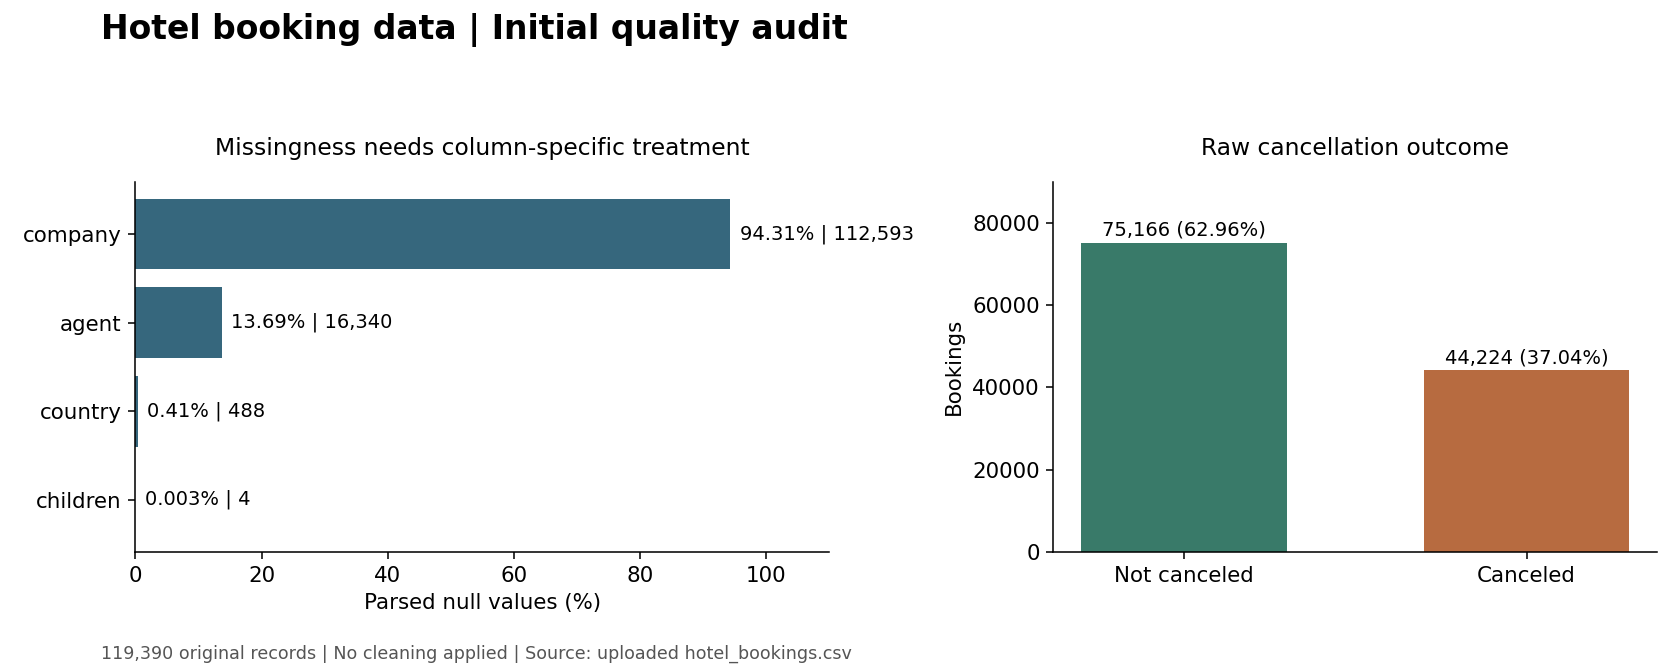

In [9]:
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.15, 1]})
axes[0].barh(missing.index, missing['percent'], color='#36677D')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 110)
axes[0].set_xlabel('Parsed null values (%)')
axes[0].set_title('Missingness needs column-specific treatment', fontsize=12, pad=14)
for i, (_, row) in enumerate(missing.iterrows()):
    precision = 3 if row['percent'] < 0.01 else 2
    label = f"{row['percent']:.{precision}f}% | {int(row['null_count']):,}"
    axes[0].text(row['percent'] + 1.5, i, label, va='center', fontsize=10)
bars = axes[1].bar(target_table['outcome'], target_table['count'], color=['#397A69', '#B76B40'], width=0.6)
axes[1].set_ylim(0, 90000)
axes[1].set_ylabel('Bookings')
axes[1].set_title('Raw cancellation outcome', fontsize=12, pad=14)
for bar, (_, row) in zip(bars, target_table.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, row['count'] + 1700,
                 f"{int(row['count']):,} ({row['percent']:.2f}%)", ha='center', fontsize=10)
fig.suptitle('Hotel booking data | Initial quality audit', x=0.06, ha='left', fontsize=17, weight='bold')
fig.text(0.06, 0.02, '119,390 original records | No cleaning applied | Source: uploaded hotel_bookings.csv',
         color='#555555', fontsize=9)
fig.tight_layout(rect=(0, 0.05, 1, 0.92))
figure_path = ROOT / 'figures' / '01_data_quality_audit.png'
fig.savefig(figure_path, dpi=140, facecolor='white')
plt.close(fig)
display(Image(filename=str(figure_path)))


## 9. Save measured evidence and verify source preservation

The machine-readable audit record contains measured counts, source identity, and runtime versions. No cleaned dataset is produced at this stage.


In [10]:
audit = {'stage': 'raw_data_audit_only',
         'audit_time_utc': datetime.now(timezone.utc).isoformat(),
         'source': file_record, 'coverage': coverage, 'runtime': versions,
         'hotel_counts': {str(k): int(v) for k, v in raw['hotel'].value_counts().items()},
         'target_counts': {str(k): int(v) for k, v in target_counts.items()},
         'cancellation_percent': float(raw['is_canceled'].mean() * 100),
         'missingness': {c: {'count': int(r['null_count']), 'percent': float(r['percent'])}
                        for c, r in missing.iterrows()},
         'duplicates': duplicate_audit, 'guest_checks': guest_audit, 'adr': adr_audit,
         'undefined_categories': undefined_counts,
         'status_matches_target': status_matches_target,
         'candidate_predictor_count': int(candidate_X.shape[1]),
         'cleaning_applied': False, 'modeling_started': False}
audit_path = ROOT / 'data' / 'audit_summary.json'
audit_path.write_text(json.dumps(audit, indent=2) + '\n', encoding='utf-8')
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_SHA256
assert raw.shape == (119390, 32)
print('Saved data/processed/audit_summary.json and figures/01_data_quality_audit.png')
print('Original CSV checksum unchanged. No rows or values were modified.')


Saved data/processed/audit_summary.json and figures/01_data_quality_audit.png
Original CSV checksum unchanged. No rows or values were modified.


## 10. Audit findings and preprocessing decisions

- The file has the expected 119,390 records, 32 columns, and a valid binary target. Cancellation prevalence is approximately 37.04%.
- Company and agent null shares differ substantially. Do not discard both based on the same missingness assumption; confirm null semantics and use categorical handling.
- There are 31,994 additional copies of full rows. Document their meaning and a partition-safe retain/remove policy before modeling.
- There are 180 known zero-total-guest records; another four totals are unknown. Zero-adult filtering would also affect 223 records with positive guest totals.
- ADR requires separate statistical and domain checks. The negative value is not caught by the raw-data IQR fence; the maximum of 5,400 is far above the next largest value of 510.
- Reservation status directly encodes the label. Both status columns must remain outside predictors.

These were the findings at the raw-data audit. eligibility and preprocessing are now implemented in Notebook 02, and development-only EDA follows below. Preserve the original source and fit learned transforms only within training folds. Predictive performance is evaluated separately in the modeling and evaluation notebooks.

## References

- Dataset source specified for this project: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- Antonio, N., de Almeida, A., and Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41-49. https://doi.org/10.1016/j.dib.2018.11.126
- Original data documentation: https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/

Exact terms for the downloaded Kaggle version still need to be recorded. The observation-time description in the original publication is relative to the day before arrival, so operational booking-time availability requires additional checking.

**descriptive analysis execution:** The five EDA code cells below ran sequentially in a fresh Python process. Actual tables and PNGs were captured into notebook outputs using a Python display adapter because this session lacks IPython/nbformat. The ten earlier raw-audit outputs are preserved from their previous IPython run and were not rerun in this analysis. Full-notebook execution in a fresh Jupyter kernel and canonical nbformat validation remain pending.


## 11. descriptive analysis — Freeze scope and generate descriptive evidence

Use only arrivals from 2015-07-01 through 2017-04-22 assigned to development. The loader verifies source/split checksums and filters aligned CSV chunks before producing summaries. Fixed preprocessing rules exclude the four policy fields, preserve unknowns, and mark negative ADR missing; no learned imputation/scaling is fitted for EDA.

For numeric statistics, missing values are excluded field by field and their counts are reported. Explicit unknown/no-agent categories are preserved. Bins used in plots are descriptive groupings, not fitted predictors or changes to the feature engineering feature schema.


In [11]:
from pathlib import Path
import hashlib
import json
import sys
import pandas as pd
import numpy as np

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/development_eda.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.development_eda import run_development_eda

eda_summary, eda_tables = run_development_eda(ROOT)
display(pd.Series({k:eda_summary[k] for k in [
    'rows','date_start','date_end','canceled','not_canceled','cancellation_percent',
    'duplicate_profile_groups','test_rows_in_eda']},name='Development cohort').to_frame())
display(eda_tables['numeric_descriptive'].round(3))
display(eda_tables['missingness'].query('raw_missing > 0').round(3))
display(eda_tables['categorical_descriptive'])


,Development cohort
rows,95415
date_start,2015-07-01
date_end,2017-04-22
canceled,34473
not_canceled,60942
cancellation_percent,36.129539
duplicate_profile_groups,67961
test_rows_in_eda,0


,field,count,missing,mean,sd,min,q1,median,q3,p95,p99,max
0,lead_time,95415.0,0,96.587,104.616,0.0,15.0,60.0,145.0,314.00,426.0,737.0
1,previous_cancellations,95415.0,0,0.106,0.938,0.0,0.0,0.0,0.0,1.00,1.0,26.0
2,previous_bookings_not_canceled,95415.0,0,0.134,1.385,0.0,0.0,0.0,0.0,0.00,3.0,61.0
3,adr,95414.0,1,93.713,46.535,0.0,65.0,88.0,115.0,173.95,231.0,5400.0
4,arrival_date_year,95415.0,0,2015.946,0.635,2015.0,2016.0,2016.0,2016.0,2017.00,2017.0,2017.0
5,arrival_date_week_number,95415.0,0,27.621,14.929,1.0,14.0,29.0,41.0,50.00,53.0,53.0
6,arrival_date_day_of_month,95415.0,0,15.642,8.705,1.0,8.0,16.0,23.0,29.00,31.0,31.0
7,stays_in_weekend_nights,95415.0,0,0.904,0.996,0.0,0.0,1.0,2.0,2.00,4.0,19.0
8,stays_in_week_nights,95415.0,0,2.452,1.907,0.0,1.0,2.0,3.0,5.00,10.0,50.0
9,adults,95415.0,0,1.842,0.597,0.0,2.0,2.0,2.0,2.00,3.0,55.0


,field,raw_missing,raw_missing_percent
9,children,4,0.004
12,country,473,0.496
22,agent,13745,14.405
23,company,89515,93.816


,field,distinct_categories,most_frequent,most_frequent_count
0,hotel,2,City Hotel,62827
1,arrival_date_month,12,October,11147
2,meal,5,BB,74920
3,country,166,PRT,41405
4,market_segment,8,Online TA,42516
5,distribution_channel,5,TA/TO,77561
6,reserved_room_type,9,A,70463
7,deposit_type,3,No Deposit,82979
8,agent,313,9,23794
9,customer_type,4,Transient,69368


## 12. Lead time and cancellation

The fixed bins cover 0–7, 8–30, 31–90, 91–180, 181–365, and 366+ days. Every rate reports its numerator and denominator. The pattern supports the predeclared longer-lead-time hypothesis as an association; it does not estimate a causal effect or establish model importance.


,lead_time_group,bookings,canceled,not_canceled,cancellation_percent
0,0–7,17247,1626,15621,9.428
1,8–30,15934,4350,11584,27.300
2,31–90,25534,9570,15964,37.479
3,91–180,18856,8202,10654,43.498
4,181–365,15765,9045,6720,57.374
5,366+,2079,1680,399,80.808


,hotel,lead_time_group,bookings,canceled,not_canceled,cancellation_percent
0,City Hotel,0–7,9397,1148,8249,12.217
1,City Hotel,8–30,10445,3219,7226,30.819
2,City Hotel,31–90,17958,7222,10736,40.216
3,City Hotel,91–180,12526,5849,6677,46.695
4,City Hotel,181–365,10781,7050,3731,65.393
5,City Hotel,366+,1720,1531,189,89.012
6,Resort Hotel,0–7,7850,478,7372,6.089
7,Resort Hotel,8–30,5489,1131,4358,20.605
8,Resort Hotel,31–90,7576,2348,5228,30.993
9,Resort Hotel,91–180,6330,2353,3977,37.172


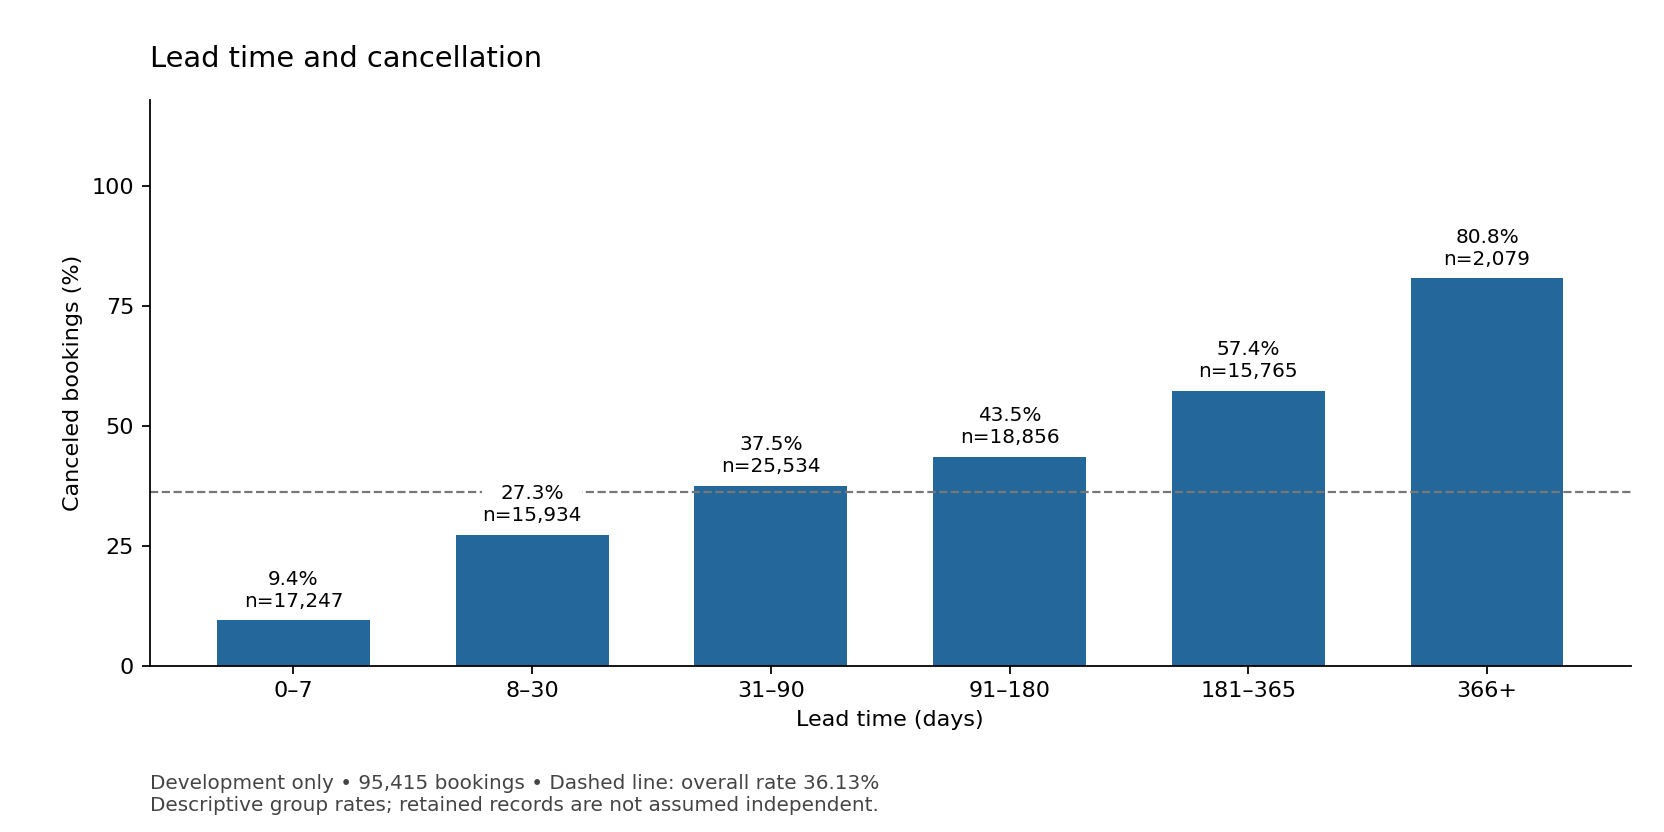

In [12]:
display(eda_tables['lead_time_rates'].round(3))
display(eda_tables['lead_time_by_hotel'].round(3))
display(Image(filename=str(ROOT / 'figures/03_lead_time_cancellation.png')))


## 13. Deposit type, with hotel stratification

Non-refundable bookings have a very high observed cancellation rate in both hotels. This does not mean non-refundable terms cause cancellation. Booking mix, operating policies, or recording timing may contribute; their effects are not established here. Refundable groups are small, especially City Hotel (nine bookings). Retain the committed factor for analysis and consider a development-only model comparison with/without it later, without selecting based on test outcomes.


,deposit_type,bookings,canceled,not_canceled,cancellation_percent
0,No Deposit,82979,22254,60725,26.819
1,Non Refund,12296,12204,92,99.252
2,Refundable,140,15,125,10.714


,hotel,deposit_type,bookings,canceled,not_canceled,cancellation_percent
0,City Hotel,No Deposit,52130,15351,36779,29.448
1,City Hotel,Non Refund,10688,10664,24,99.775
2,City Hotel,Refundable,9,4,5,44.444
3,Resort Hotel,No Deposit,30849,6903,23946,22.377
4,Resort Hotel,Non Refund,1608,1540,68,95.771
5,Resort Hotel,Refundable,131,11,120,8.397


,hotel,bookings,canceled,not_canceled,cancellation_percent
0,City Hotel,62827,26019,36808,41.414
1,Resort Hotel,32588,8454,24134,25.942


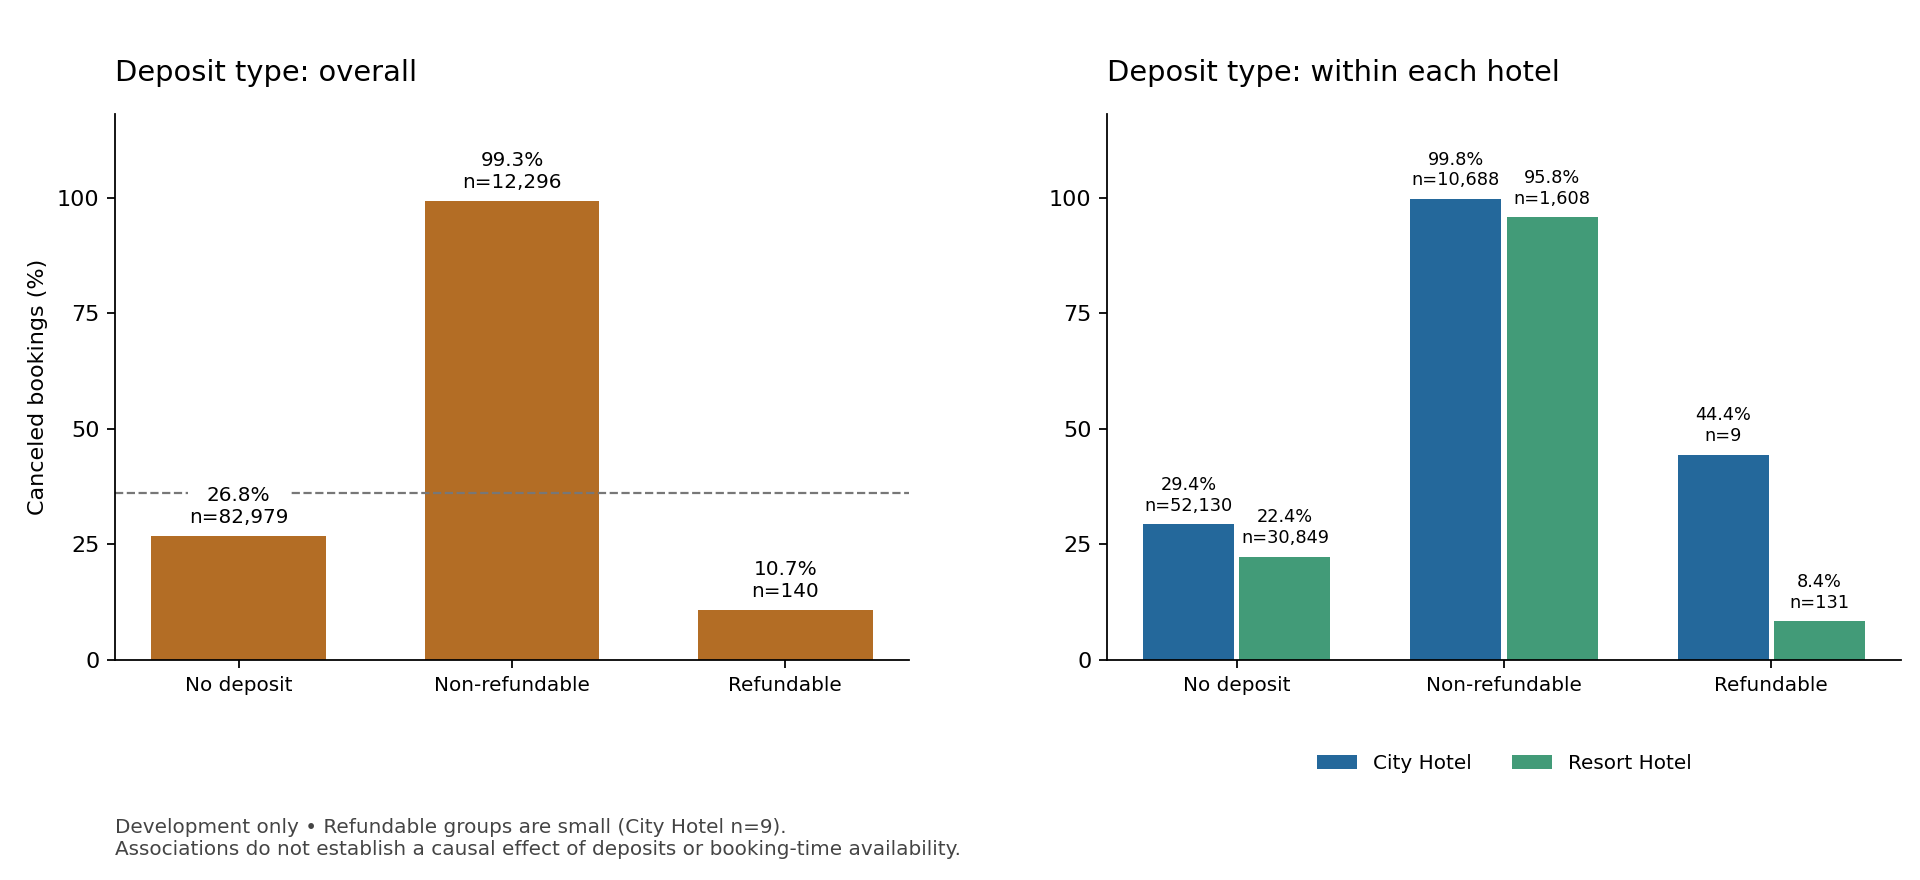

In [13]:
display(eda_tables['deposit_rates'].round(3))
display(eda_tables['deposit_by_hotel'].round(3))
display(eda_tables['hotel_rates'].round(3))
display(Image(filename=str(ROOT / 'figures/04_deposit_cancellation.png')))


## 14. Prior cancellations and repeated-record sensitivity

The hypothesis is not supported as a simple monotonic count relationship: exactly one prior cancellation has a much higher observed rate than two to three. Always read the group sizes.

Main rates weight each booking equally, as in the retained dataset. For a sensitivity analysis, each eligibility duplicate-profile group receives total weight one. If identical predictors have conflicting labels, retain their mean outcome; do not pick the first label. This alternative weighting answers a different descriptive question and is not a replacement dataset, new cleaning rule, or model-training weight.

Repeated bookings are not assumed independent, so this report does not add naive row-independent confidence intervals or claim statistical significance.


,prior_cancellations_group,bookings,canceled,not_canceled,cancellation_percent
0,0,89079,28564,60515,32.066
1,1,5951,5692,259,95.648
2,2–3,163,51,112,31.288
3,4+,222,166,56,74.775


,prior_cancellations_group,bookings,duplicate_groups,weight_sum,weighted_canceled,equal_group_cancellation_percent
0,0,89079,66444,66444.0,16079.751,24.200
1,1,5951,1286,1286.0,1027.000,79.860
2,2–3,163,155,155.0,43.000,27.742
3,4+,222,76,76.0,20.000,26.316


,lead_time_group,bookings,duplicate_groups,weight_sum,weighted_canceled,equal_group_cancellation_percent
0,0–7,17247,15889,15889.0,1297.850,8.168
1,8–30,15934,13489,13489.0,3287.043,24.368
2,31–90,25534,18992,18992.0,5851.150,30.809
3,91–180,18856,12519,12519.0,4154.100,33.182
4,181–365,15765,6762,6762.0,2433.607,35.989
5,366+,2079,310,310.0,146.000,47.097


,deposit_type,bookings,duplicate_groups,weight_sum,weighted_canceled,equal_group_cancellation_percent
0,No Deposit,82979,67054,67054.0,16395.958,24.452
1,Non Refund,12296,820,820.0,766.650,93.494
2,Refundable,140,87,87.0,7.143,8.210


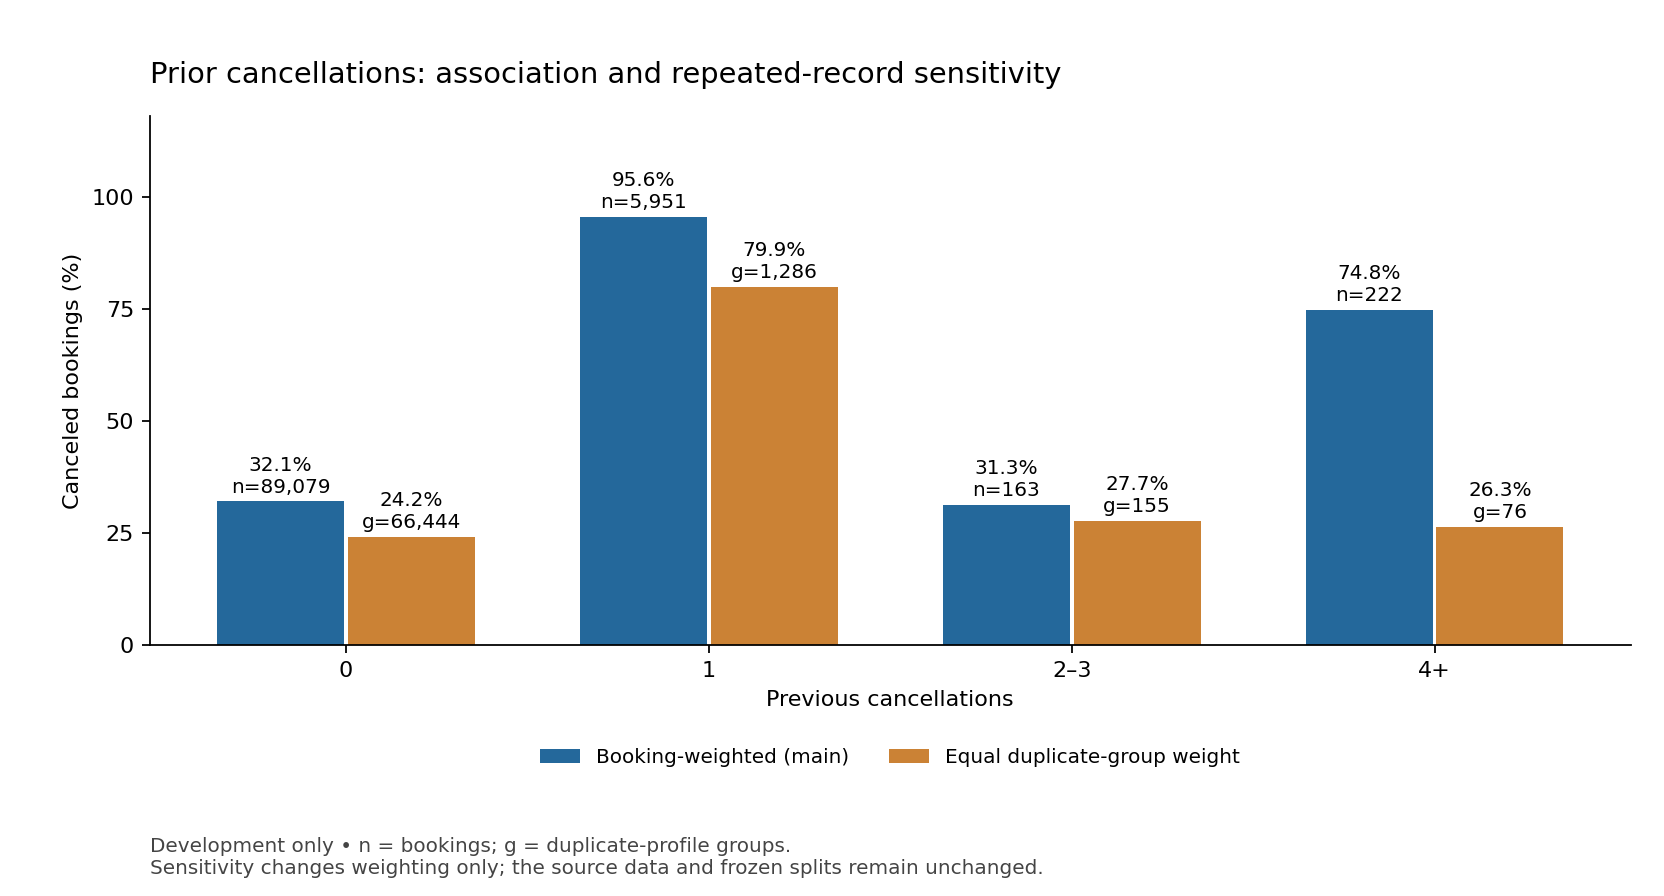

Overall booking-weighted cancellation rate: 36.13 %
Overall equal-profile-group rate: 25.26 %


In [14]:
display(eda_tables['prior_cancellation_rates'].round(3))
display(eda_tables['sensitivity_prior_cancellations'].round(3))
display(eda_tables['sensitivity_lead_time'].round(3))
display(eda_tables['sensitivity_deposit'].round(3))
display(Image(filename=str(ROOT / 'figures/05_prior_cancellations_sensitivity.png')))
print('Overall booking-weighted cancellation rate:', round(eda_summary['cancellation_percent'],2),'%')
print('Overall equal-profile-group rate:', round(eda_summary['equal_group_cancellation_percent'],2),'%')


## 15. Main observations

1. Cancellation rates rise across the lead-time bins: **9.43%** for 0–7 days (n=17,247) to **80.81%** for 366+ days (n=2,079).
2. Non-refundable bookings have **99.25%** cancellations (n=12,296), versus **26.82%** without a deposit (n=82,979). Refundable bookings have **10.71%**, but n=140 is small. The association remains strong within each hotel; causality and booking-time availability are not established.
3. Prior cancellations are non-monotonic: **32.07%, 95.65%, 31.29%, and 74.77%** for 0, 1, 2–3, and 4+ respectively. The last two groups have only 163 and 222 rows. Avoid claiming that every extra prior cancellation increases risk.
4. City Hotel has **41.41%** cancellations (n=62,827), compared with **25.94%** for Resort Hotel (n=32,588). Hotel composition matters when interpreting pooled patterns.
5. Equal weighting of duplicate-profile groups changes the overall rate from **36.13% to 25.26%**. In the 4+ prior-cancellation group it changes **74.77% to 26.32%**. This shows sensitivity to repeated-record frequency; neither weighting is asserted to be the true underlying population rate.

These observations guide later feature construction and validation; they do not answer model accuracy/ranking questions yet. Monthly summaries are provided as supporting tables; April 2017 is partial through the 22nd, so volume comparisons need that qualification.

In [15]:
eda_dir = ROOT / 'data/processed/eda'
assert json.loads((eda_dir / 'eda_summary.json').read_text()) == eda_summary
assert eda_summary['rows'] == 95415 and eda_summary['canceled'] == 34473
assert eda_summary['test_rows_in_eda'] == 0
for name in ['lead_time_rates','deposit_rates','prior_cancellation_rates','hotel_rates','monthly_rates']:
    assert eda_tables[name]['bookings'].sum() == eda_summary['rows']
    assert eda_tables[name]['canceled'].sum() == eda_summary['canceled']
for relative, digest in eda_summary['output_sha256'].items():
    assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == digest
split_dir = ROOT / 'data/processed/splits'
plan = json.loads((split_dir / 'validation_split_plan.json').read_text())
assert hashlib.sha256((split_dir / plan['assignment_file']).read_bytes()).hexdigest() == plan['assignment_sha256']
for filename,digest in plan['upstream_output_sha256'].items():
    assert hashlib.sha256((ROOT / 'data/processed' / filename).read_bytes()).hexdigest() == digest
if (ROOT / 'data/raw/hotel_bookings.csv').is_file():
    assert hashlib.sha256((ROOT / 'data/raw/hotel_bookings.csv').read_bytes()).hexdigest() == plan['source_sha256']
print('PASS: development-only totals reconcile; output hashes and upstream data/split hashes match.')


PASS: development-only totals reconcile; output hashes and upstream data/split hashes match.
